In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("healthcare_claims_full_dirty.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Claim_ID         4720 non-null   float64
 1   Patient_Age      4734 non-null   float64
 2   Gender           4733 non-null   object 
 3   City             4724 non-null   object 
 4   Policy_Type      4725 non-null   object 
 5   Hospital_Type    4726 non-null   object 
 6   Claim_Amount     4727 non-null   float64
 7   Approved_Amount  4720 non-null   float64
 8   Claim_Status     4725 non-null   object 
 9   Fraud_Flag       4723 non-null   float64
 10  Days_To_Settle   4734 non-null   float64
dtypes: float64(6), object(5)
memory usage: 451.3+ KB


In [5]:
df.head()

,Claim_ID,Patient_Age,Gender,City,Policy_Type,Hospital_Type,Claim_Amount,Approved_Amount,Claim_Status,Fraud_Flag,Days_To_Settle
0,30001.0,69.0,Male,Bangalore,Basic,NaN,102590.55,52944.92,Pending,1.0,36.0
1,30002.0,32.0,Male,Bangalore,Premium,Private,37498.74,48520.11,NaN,0.0,46.0
2,30003.0,78.0,Female,Mumbai,Gold,Government,46435.37,52135.15,Pending,1.0,37.0
3,30004.0,38.0,Male,Delhi,Premium,Private,-582.78,31363.99,Approved,1.0,18.0
4,30005.0,41.0,Female,Bangalore,NaN,Private,50190.30,88939.14,NaN,1.0,43.0


In [6]:
df.isnull().sum()


Claim_ID           530
Patient_Age        516
Gender             517
City               526
Policy_Type        525
Hospital_Type      524
Claim_Amount       523
Approved_Amount    530
Claim_Status       525
Fraud_Flag         527
Days_To_Settle     516
dtype: int64

In [7]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Claim_ID
[30001. 30002. 30003. ... 34998. 34999. 35000.]

Column: Patient_Age
[69. 32. 78. 38. 41. 20. 39. 70. 19. 47. nan 81. 77. 50. 75. 66. 76. 59.
 79. 64. 68. 72. 24. 56. 35. 21. 31. 26. 61. 25. 52. 53. 67. 23. 71. 65.
 57. 43. 58. 46. 62. 80. 22. 45. 29. 51. 40. 54. 82. 18. 44. 60. 30. 49.
 83. 74. 73. 36. 34. 55. 28. 33. 37. 84. 48. 42. 63. 27.]

Column: Gender
['Male' 'Female' 'Other' nan]

Column: City
['Bangalore' 'Mumbai' 'Delhi' 'Hyderabad' 'Chennai' nan]

Column: Policy_Type
['Basic' 'Premium' 'Gold' nan]

Column: Hospital_Type
[nan 'Private' 'Government']

Column: Claim_Amount
[102590.55  37498.74  46435.37 ...  46445.63  39736.56  75447.28]

Column: Approved_Amount
[52944.92 48520.11 52135.15 ... 84627.16 23237.42 46697.48]

Column: Claim_Status
['Pending' nan 'Approved' 'Rejected']

Column: Fraud_Flag
[ 1.  0. nan]

Column: Days_To_Settle
[36. 46. 37. 18. 43. 29. 15. 59. 28. 53. nan 33.  2. 35. 21. 64. 45. 20.
  4. 52. 39. 71. 12. 55. 48.  9. 69. 57. 17. 22. 19

In [8]:
df1=df.copy()

In [9]:
df.shape

(5250, 11)

In [10]:
(df.isnull().sum() / len(df)) * 100

Claim_ID           10.095238
Patient_Age         9.828571
Gender              9.847619
City               10.019048
Policy_Type        10.000000
Hospital_Type       9.980952
Claim_Amount        9.961905
Approved_Amount    10.095238
Claim_Status       10.000000
Fraud_Flag         10.038095
Days_To_Settle      9.828571
dtype: float64

In [11]:
df=df.dropna(subset=['Claim_ID','Fraud_Flag'])

In [12]:
df.isnull().sum()

Claim_ID             0
Patient_Age        426
Gender             438
City               424
Policy_Type        410
Hospital_Type      424
Claim_Amount       436
Approved_Amount    424
Claim_Status       414
Fraud_Flag           0
Days_To_Settle     415
dtype: int64

In [13]:
df.head()

,Claim_ID,Patient_Age,Gender,City,Policy_Type,Hospital_Type,Claim_Amount,Approved_Amount,Claim_Status,Fraud_Flag,Days_To_Settle
0,30001.0,69.0,Male,Bangalore,Basic,NaN,102590.55,52944.92,Pending,1.0,36.0
1,30002.0,32.0,Male,Bangalore,Premium,Private,37498.74,48520.11,NaN,0.0,46.0
2,30003.0,78.0,Female,Mumbai,Gold,Government,46435.37,52135.15,Pending,1.0,37.0
3,30004.0,38.0,Male,Delhi,Premium,Private,-582.78,31363.99,Approved,1.0,18.0
4,30005.0,41.0,Female,Bangalore,NaN,Private,50190.30,88939.14,NaN,1.0,43.0


Patient_Age        426
Gender             438
City               424
Policy_Type        410
Hospital_Type      424
Claim_Amount       436
Approved_Amount    424
Claim_Status       414
Fraud_Flag           0
Days_To_Settle     415

In [14]:
df1=df.copy()

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4245 entries, 0 to 5248
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Claim_ID         4245 non-null   float64
 1   Patient_Age      3819 non-null   float64
 2   Gender           3807 non-null   object 
 3   City             3821 non-null   object 
 4   Policy_Type      3835 non-null   object 
 5   Hospital_Type    3821 non-null   object 
 6   Claim_Amount     3809 non-null   float64
 7   Approved_Amount  3821 non-null   float64
 8   Claim_Status     3831 non-null   object 
 9   Fraud_Flag       4245 non-null   float64
 10  Days_To_Settle   3830 non-null   float64
dtypes: float64(6), object(5)
memory usage: 398.0+ KB


In [16]:
df['Claim_Amount'] = df['Claim_Amount'].abs()
df['Approved_Amount'] = df['Approved_Amount'].abs()

In [17]:
col1=['Patient_Age','Claim_Amount','Days_To_Settle','Approved_Amount']
for col in col1:
    df[col]=df[col].fillna(df[col].median())

In [18]:
df.isnull().sum()

Claim_ID             0
Patient_Age          0
Gender             438
City               424
Policy_Type        410
Hospital_Type      424
Claim_Amount         0
Approved_Amount      0
Claim_Status       414
Fraud_Flag           0
Days_To_Settle       0
dtype: int64

In [19]:
col2=['Gender','City','Policy_Type','Hospital_Type','Claim_Status']
for col in col2:
    df[col]=df[col].fillna(df[col].mode()[0])

In [20]:
df.isnull().sum()

Claim_ID           0
Patient_Age        0
Gender             0
City               0
Policy_Type        0
Hospital_Type      0
Claim_Amount       0
Approved_Amount    0
Claim_Status       0
Fraud_Flag         0
Days_To_Settle     0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4245 entries, 0 to 5248
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Claim_ID         4245 non-null   float64
 1   Patient_Age      4245 non-null   float64
 2   Gender           4245 non-null   object 
 3   City             4245 non-null   object 
 4   Policy_Type      4245 non-null   object 
 5   Hospital_Type    4245 non-null   object 
 6   Claim_Amount     4245 non-null   float64
 7   Approved_Amount  4245 non-null   float64
 8   Claim_Status     4245 non-null   object 
 9   Fraud_Flag       4245 non-null   float64
 10  Days_To_Settle   4245 non-null   float64
dtypes: float64(6), object(5)
memory usage: 398.0+ KB


In [22]:
col3=['Patient_Age','Claim_ID','Days_To_Settle','Fraud_Flag']
for col in col3:
    df[col]=df[col].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4245 entries, 0 to 5248
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Claim_ID         4245 non-null   int64  
 1   Patient_Age      4245 non-null   int64  
 2   Gender           4245 non-null   object 
 3   City             4245 non-null   object 
 4   Policy_Type      4245 non-null   object 
 5   Hospital_Type    4245 non-null   object 
 6   Claim_Amount     4245 non-null   float64
 7   Approved_Amount  4245 non-null   float64
 8   Claim_Status     4245 non-null   object 
 9   Fraud_Flag       4245 non-null   int64  
 10  Days_To_Settle   4245 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 398.0+ KB


In [24]:
df.head()

,Claim_ID,Patient_Age,Gender,City,Policy_Type,Hospital_Type,Claim_Amount,Approved_Amount,Claim_Status,Fraud_Flag,Days_To_Settle
0,30001,69,Male,Bangalore,Basic,Government,102590.55,52944.92,Pending,1,36
1,30002,32,Male,Bangalore,Premium,Private,37498.74,48520.11,Rejected,0,46
2,30003,78,Female,Mumbai,Gold,Government,46435.37,52135.15,Pending,1,37
3,30004,38,Male,Delhi,Premium,Private,582.78,31363.99,Approved,1,18
4,30005,41,Female,Bangalore,Premium,Private,50190.30,88939.14,Rejected,1,43


In [25]:
df['Claim_Amount'].max()
df['Claim_Amount'].min()


196.59

In [28]:
print("Avg Claim:", df["Claim_Amount"].mean())
print("Avg Days:", df["Days_To_Settle"].mean())


Avg Claim: 60041.13444287397
Avg Days: 37.13922261484099


<Axes: xlabel='Claim_Amount', ylabel='Count'>

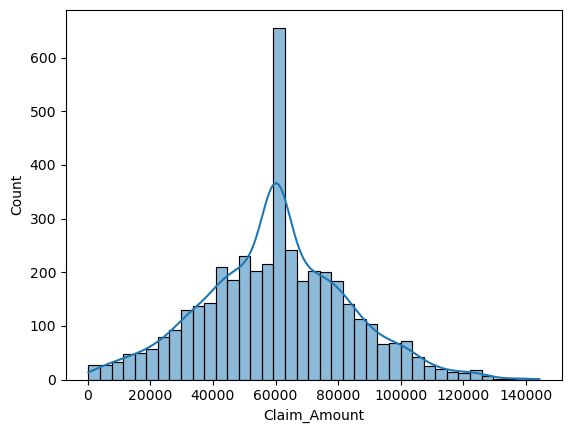

In [29]:
sns.histplot(df['Claim_Amount'],kde=True)

In [30]:
q1=np.quantile(df['Claim_Amount'],0.25)
q2=np.quantile(df['Claim_Amount'],0.50)
q3=np.quantile(df['Claim_Amount'],0.75)
IQR=q3-q1
lower=q1-(1.5*IQR)
upper=q3+(1.5*IQR)
print(lower,q1,q2,q3,upper)

-17.085000000006403 44913.36 59976.5 74866.99 119797.43500000001


In [31]:
df['Claim_Amount'].median()

59976.5

<Axes: ylabel='Claim_Amount'>

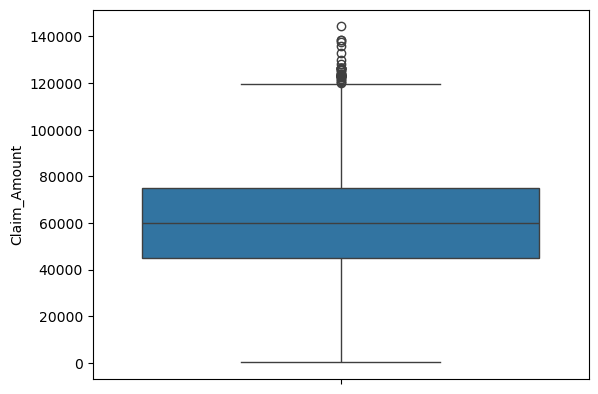

In [32]:
sns.boxplot(df['Claim_Amount'])

In [33]:
df['Claim_Amount_outlier'] = (
    (df['Claim_Amount'] > upper) | 
    (df['Claim_Amount'] < lower)
).astype(int)

In [34]:
df['Claim_Amount_outlier'].unique()

array([0, 1])

In [35]:
df['Approval_Rate'] = df['Approved_Amount'] / df['Claim_Amount']
df['High_Claim'] = df['Claim_Amount'] > 100000

In [36]:
df.head()

,Claim_ID,Patient_Age,Gender,City,Policy_Type,Hospital_Type,Claim_Amount,Approved_Amount,Claim_Status,Fraud_Flag,Days_To_Settle,Claim_Amount_outlier,Approval_Rate,High_Claim
0,30001,69,Male,Bangalore,Basic,Government,102590.55,52944.92,Pending,1,36,0,0.516080,True
1,30002,32,Male,Bangalore,Premium,Private,37498.74,48520.11,Rejected,0,46,0,1.293913,False
2,30003,78,Female,Mumbai,Gold,Government,46435.37,52135.15,Pending,1,37,0,1.122747,False
3,30004,38,Male,Delhi,Premium,Private,582.78,31363.99,Approved,1,18,0,53.817890,False
4,30005,41,Female,Bangalore,Premium,Private,50190.30,88939.14,Rejected,1,43,0,1.772038,False


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4245 entries, 0 to 5248
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Claim_ID              4245 non-null   int64  
 1   Patient_Age           4245 non-null   int64  
 2   Gender                4245 non-null   object 
 3   City                  4245 non-null   object 
 4   Policy_Type           4245 non-null   object 
 5   Hospital_Type         4245 non-null   object 
 6   Claim_Amount          4245 non-null   float64
 7   Approved_Amount       4245 non-null   float64
 8   Claim_Status          4245 non-null   object 
 9   Fraud_Flag            4245 non-null   int64  
 10  Days_To_Settle        4245 non-null   int64  
 11  Claim_Amount_outlier  4245 non-null   int64  
 12  Approval_Rate         4245 non-null   float64
 13  High_Claim            4245 non-null   bool   
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 468.4+ KB


In [38]:
df.isnull().sum()

Claim_ID                0
Patient_Age             0
Gender                  0
City                    0
Policy_Type             0
Hospital_Type           0
Claim_Amount            0
Approved_Amount         0
Claim_Status            0
Fraud_Flag              0
Days_To_Settle          0
Claim_Amount_outlier    0
Approval_Rate           0
High_Claim              0
dtype: int64

In [39]:
df['Approved_gt_Claim_Flag'] = (df['Approved_Amount'] > df['Claim_Amount']).astype(int)

In [40]:
df[df['Claim_Amount'] > df['Approved_Amount']].shape

(2652, 15)

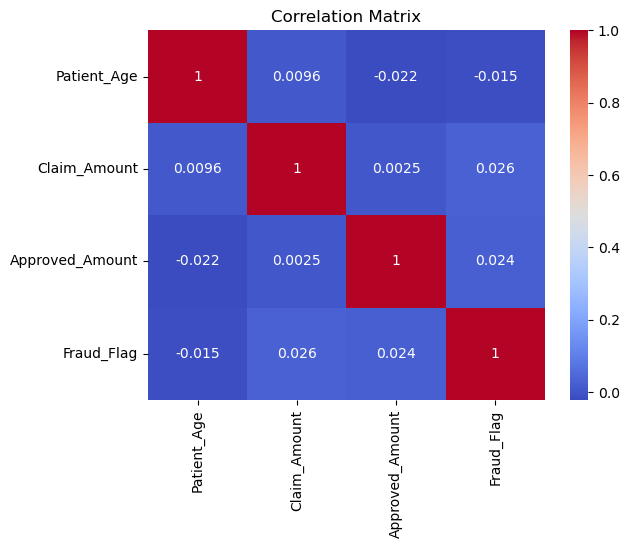

In [46]:
corr_matrix = df[["Patient_Age", "Claim_Amount", "Approved_Amount", "Fraud_Flag"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [50]:
df.to_csv("Healthcare_claims_Clean.csv", index=False)

In [51]:
df.shape

(4245, 15)